Begin Exercise
 1Exercise:
As we mentioned, cross validation is usually preferred over a validation set. Use scikit-learn cross_val_score from the model_selection module to find cross validated accuracy scores for the iris data.

In [1]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()
X, y = iris_dataset.data, iris_dataset.target


In [2]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
X,y, test_size=0.3,random_state=5)

In [3]:
type(iris_dataset)

sklearn.utils._bunch.Bunch

In [4]:
iris_dataset.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
print(f" Training set score: {lda.score(X_train, y_train):.2f}")
print(f" Test set score: {lda.score(X_test, y_test):.2f}")

 Training set score: 0.99
 Test set score: 0.96


In [6]:
print("Training set score: {:.2f}".format(lda.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lda.score(X_test, y_test)))

Training set score: 0.99
Test set score: 0.96


In [7]:
print(f" {'Training set score':<20} {lda.score(X_train, y_train):.2f}")
print(f" {'Test set score':<20} {lda.score(X_test, y_test):.2f}")

 Training set score   0.99
 Test set score       0.96


In [8]:
from sklearn.model_selection import cross_val_score

In [9]:
scores = cross_val_score(lda, X, y, cv=5, scoring='accuracy')

In [10]:
print(f"Accuracy scores for each fold: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy scores for each fold: [1.         1.         0.96666667 0.93333333 1.        ]
Mean Accuracy: 0.9800 (+/- 0.0267)


end of exercise 1

Begin Exercise 2: manually split data using binomial


In [11]:
import numpy as np
iris = load_iris()
X, y = iris.data, iris.target
train_ratio = 0.7  # 70% train, 30% test
seed = 42
rng = np.random.default_rng(seed)
mask = rng.binomial(n=1, p=train_ratio, size=len(X)).astype(bool)
X_train, y_train = X[mask], y[mask]
X_test, y_test = X[~mask], y[~mask]

In [12]:
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)} ({len(X_train)/len(X):.1%})")
print(f"Test samples:  {len(X_test)} ({len(X_test)/len(X):.1%})")

Total samples: 150
Train samples: 111 (74.0%)
Test samples:  39 (26.0%)


Exercise 3:
Find the test accuracy "manually" by finding the proportion of correct predictions.

In [13]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)

In [15]:
correct_predictions = np.sum(y_pred == y_test)
total_samples = len(y_test)
manual_accuracy = correct_predictions / total_samples
manual_accuracy_mean = np.mean(y_pred == y_test)

In [17]:
print(f"Correct Predictions : {correct_predictions} / {total_samples}")
print(f"Manual Test Accuracy: {manual_accuracy:.4f}")
sklearn_accuracy = lda.score(X_test, y_test)
print(f"Scikit-learn Score : {sklearn_accuracy:.4f}")

Correct Predictions : 39 / 39
Manual Test Accuracy: 1.0000
Scikit-learn Score : 1.0000


Exercise 4:
Try fitting a linear support vector machine classifier. Use default parameters as we did with naive bayes. But do take a look at the parameters.

In [21]:
from sklearn.svm import SVC
iris = load_iris()
X, y = iris.data, iris.target
rng = np.random.default_rng(seed=42)
mask = rng.binomial(n=1, p=0.7, size=len(X)).astype(bool)

X_train, y_train = X[mask], y[mask]
X_test, y_test = X[~mask], y[~mask]
svm_model = SVC(kernel="linear", random_state=42)
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
manual_accuracy = np.mean(y_pred == y_test)

In [ ]:
print(f"Correct predictions: {np.sum(y_pred == y_test)} / {len(y_test)}")
print(f"Manual Test Accuracy: {manual_accuracy:.4f}")
print("\n--- Linear SVM Key Default Parameters ---")
params = svm_model.get_params()
for param_name in params:
    print(f"{param_name}: {params[param_name]}")

Correct predictions: 38 / 39
Manual Test Accuracy: 0.9744

--- Linear SVM Key Default Parameters ---
C: 1.0
break_ties: False
cache_size: 200
class_weight: None
coef0: 0.0
decision_function_shape: ovr
degree: 3
gamma: scale
kernel: linear
max_iter: -1
probability: False
random_state: 42
shrinking: True
tol: 0.001
verbose: False


Exercise 4:
Fit a linear regression for mpg with wt, disp, and hp as predictors. Find rmse and r-squared errors, and find the equation for the fit.



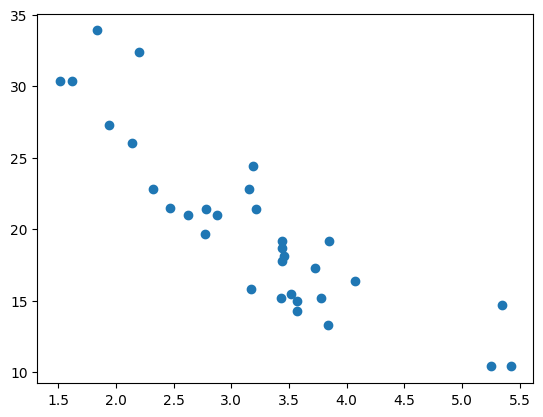

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas
cars = pandas.read_csv('cars.csv')
cars.head()
import matplotlib.pyplot as plt
plt.scatter(x=cars['wt'], y=cars['mpg'])

In [38]:
from sklearn.linear_model import LinearRegression
lrm = LinearRegression()

X = cars[['wt', 'disp', 'hp']]
y = cars['mpg']

model = lrm.fit(X, y)
y_pred = model.predict(X)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)
intercept = model.intercept_
coef_wt, coef_disp, coef_hp = model.coef_

print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"mpg = {intercept:.4f} + ({coef_wt:.4f} * wt) + ({coef_disp:.4f} * disp) + ({coef_hp:.4f} * hp)")

RMSE: 2.4685
R-squared: 0.8268
mpg = 37.1055 + (-3.8009 * wt) + (-0.0009 * disp) + (-0.0312 * hp)


Exercise 5:
Find the rmse score "manually".

In [41]:
manual_rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(manual_rmse)

2.468493181075731
